**Objectif du projet: Prédiction du CA (Sales_Amount)**

Phase 1  Collecte et exploration

In [8]:
!pip install -U gradio

In [9]:
import gradio as gr
gr.__version__

'6.12.0'

In [45]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
RANDOM_STATE = 42
import joblib
import json
import joblib
import pandas as pd
import gradio as gr


In [11]:
df =pd.read_csv("Fashion_sales.csv")
df.head()

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66


In [12]:
print("Shape:", df.shape)
df.info()
print(df.describe(include="all").T)

# Vérification variable cible
print(df["Profit"].describe())

Shape: (2500, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Customer_Name     2500 non-null   str    
 2   Product_Category  2500 non-null   str    
 3   Product_Name      2500 non-null   str    
 4   Units_Sold        1194 non-null   float64
 5   Unit_Price        1290 non-null   float64
 6   Discount_%        849 non-null    float64
 7   Sales_Amount      2500 non-null   float64
 8   Order_Date        1894 non-null   str    
 9   City              2500 non-null   str    
 10  Segment           1679 non-null   str    
 11  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), str(6)
memory usage: 349.3 KB
                   count unique            top freq         mean          std  \
Order_ID          2500.0    NaN            NaN  NaN      2193.06   748.063846   
Custom

Phase 2: Visualisation

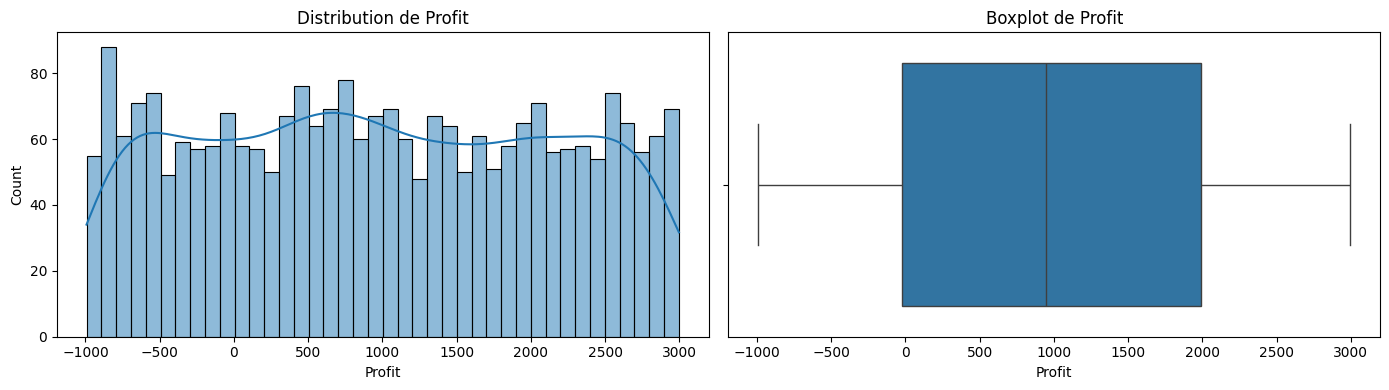

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["Profit"], bins=40, kde=True, ax=ax[0])
ax[0].set_title("Distribution de Profit")

sns.boxplot(x=df["Profit"], ax=ax[1])
ax[1].set_title("Boxplot de Profit")

plt.tight_layout()
plt.show()

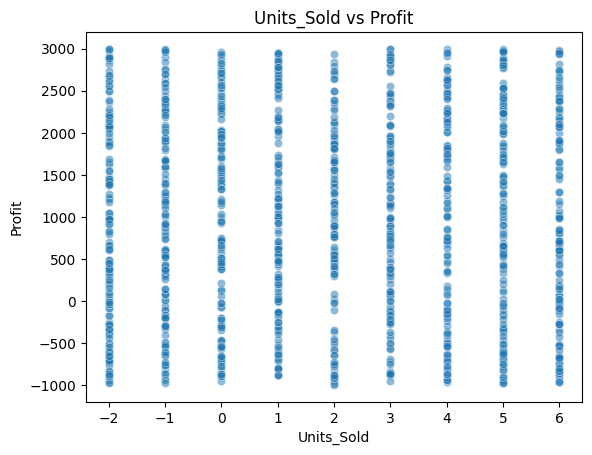

In [14]:
sns.scatterplot(data=df, x="Units_Sold", y="Profit", alpha=0.5)
plt.title("Units_Sold vs Profit")
plt.show()

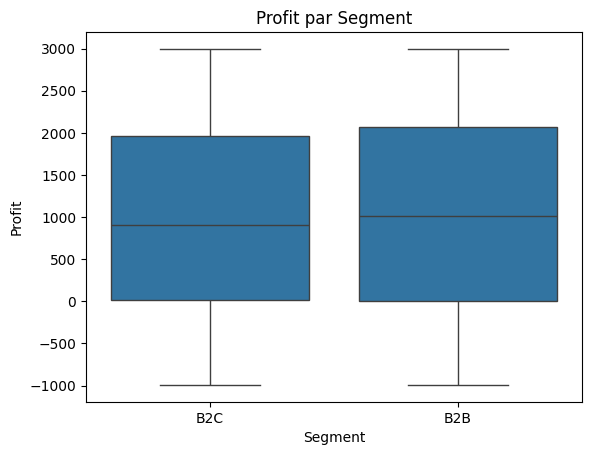

In [15]:
sns.boxplot(data=df, x="Segment", y="Profit")
plt.title("Profit par Segment")
plt.show()

**Phase 3 — Nettoyage & préparation**

In [16]:
Valeurs_manquantes = df.isna().sum().sort_values(ascending=False)
print(Valeurs_manquantes[Valeurs_manquantes > 0])

print("Doublons:", df.duplicated().sum())

Discount_%    1651
Units_Sold    1306
Unit_Price    1210
Segment        821
Order_Date     606
dtype: int64
Doublons: 0


In [17]:
target = "Profit"

numeric_features = ["Units_Sold", "Unit_Price", "Discount_%"]
categorical_features = ["Segment", "Product_Category", "City"]

features = numeric_features + categorical_features

In [18]:
target="Profit"
features = ["Units_Sold", "Unit_Price", "Discount_%", "Segment", "Product_Category", "City"]
df_model = df[features + [target]].copy()

In [20]:
target = "Profit"
features = ["Units_Sold","Unit_Price","Discount_%","Segment","Product_Category","City"]

X = df_model[features]
y = df_model[target]

X.shape, y.shape

((2500, 6), (2500,))

« X contient les 6 les features, y = Profit »

In [21]:
df_model = df_model[df_model["Units_Sold"].isna() | (df_model["Units_Sold"] >= 0)].copy()

In [22]:
# 1) Combien de valeurs négatives ?
(df_model["Units_Sold"] < 0).sum()

np.int64(0)

In [23]:
# Traitement des réduction > 100%
df_model["Discount_%"] = df_model["Discount_%"].clip(0, 1)

In [24]:
# Vérification> 1
(df_model["Discount_%"] > 1).sum(), df_model["Discount_%"].max()

(np.int64(0), 1.0)

In [25]:
target = "Profit"
features = ["Units_Sold", "Unit_Price", "Discount_%", "Segment", "Product_Category", "City"]

df_model = df[features + [target]].copy()

df_model.isna().sum().sort_values(ascending=False)

Discount_%          1651
Units_Sold          1306
Unit_Price          1210
Segment              821
Product_Category       0
City                   0
Profit                 0
dtype: int64

In [26]:
# Identification des outliers de notre valeur variable cible par méthode IQR
Q1 = df_model["Profit"].quantile(0.25)
Q3 = df_model["Profit"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_bound, upper_bound


(np.float64(-19.67),
 np.float64(1993.515),
 np.float64(2013.1850000000002),
 np.float64(-3039.4475),
 np.float64(5013.2925000000005))

In [27]:
outliers_mask = (df_model["Profit"] < lower_bound) | (df_model["Profit"] > upper_bound)
outliers_count = outliers_mask.sum()
outliers_pct = outliers_count / len(df_model) * 100

outliers_count, outliers_pct

(np.int64(0), np.float64(0.0))

In [28]:
# Traitement des outliers par la méthode de winsorisation
df_model_iqr = df_model.copy()
df_model_iqr["Profit"] = df_model_iqr["Profit"].clip(lower_bound, upper_bound)

df_model_iqr["Profit"].describe()

count    2500.000000
mean      981.569032
std      1159.159244
min      -992.610000
25%       -19.670000
50%       947.885000
75%      1993.515000
max      2997.110000
Name: Profit, dtype: float64

- Les profits trop faibles sont réduits àlower_bound
- Les profits trop élevés sont réduits àupper_bound
- On garde toutes les lignes (pas de perte de données)

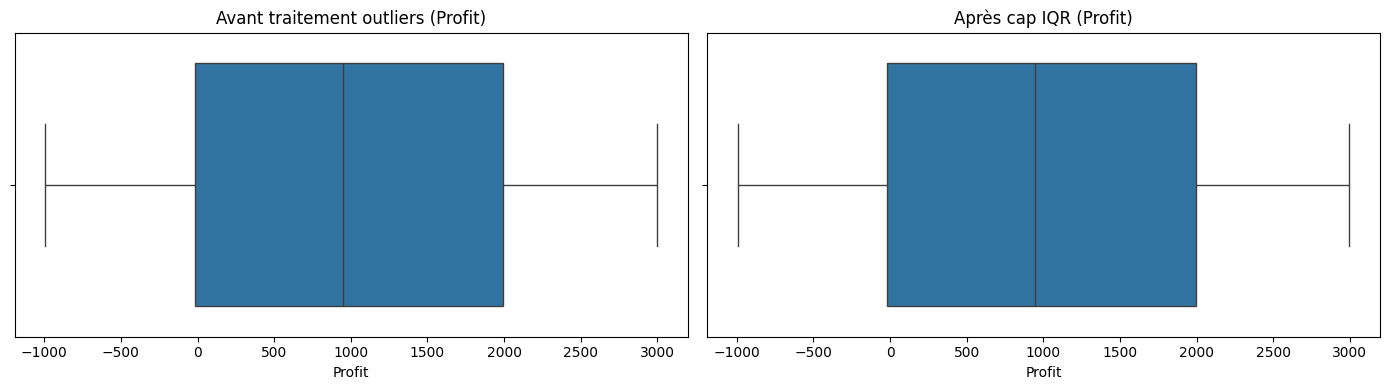

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))

sns.boxplot(x=df_model["Profit"], ax=ax[0])
ax[0].set_title("Avant traitement outliers (Profit)")

sns.boxplot(x=df_model_iqr["Profit"], ax=ax[1])
ax[1].set_title("Après cap IQR (Profit)")

plt.tight_layout()
plt.show()

**Phase 4 — Normalisation & séparation**

In [30]:
#Séparation des données d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2000, 6) Test: (500, 6)


In [31]:
#Définition des colonnes numérique et catégorielles
target = "Profit"

numeric_features = ["Units_Sold", "Unit_Price", "Discount_%"]
categorical_features = ["Segment", "Product_Category", "City"]

features = numeric_features + categorical_features

In [32]:
# le préprocesseur (imputation + mise à l'échelle + encodage)
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Préprocesseur (Pipeline sklearn)
On construit un préprocesseur unique avec ColumnTransformer afin d'appliquer automatiquement les transformations adaptées à chaque type de variable.

Pour les variables numériques ( Units_Sold, Unit_Price, Discount_%) : on impute les valeurs manquantes avec la médiane, puis on standardise avec StandardScalerpour mettre toutes les caractéristiques sur une échelle comparable.
Pour les variables catégorielles ( Segment, Product_Category, City) : on impute les valeurs manquantes avec la valeur la plus fréquente, puis on encode en One-Hot via OneHotEncoder(handle_unknown="ignore")afin de transformer les catégories en variables numériques
Ce choix garantit un pipeline reproductible , évitant la fuite de données et est directement réutilisable pour le déploiement sur (Gradio/Hugging Face).

In [33]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)

Processed train shape: (2000, 20)
Processed test shape : (500, 20)


**Phase 5 — Modélisation & évaluation**

In [34]:
# On Crée une fonction d'évaluation

def train_eval(name, model):
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    return {"model": name, "rmse": rmse, "r2": r2, "pipeline": pipe}

results = []
results.append(train_eval("LinearRegression", LinearRegression()))
results.append(train_eval("RandomForest", RandomForestRegressor(
    n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1
)))
results.append(train_eval("GradientBoosting", GradientBoostingRegressor(
    random_state=RANDOM_STATE
)))

df_results = pd.DataFrame([{k:v for k,v in r.items() if k!="pipeline"} for r in results]).sort_values("rmse")
df_results

,model,rmse,r2
0,LinearRegression,1159.686363,-0.016490
2,GradientBoosting,1176.863681,-0.046826
1,RandomForest,1238.301221,-0.158976


On scale tout dans une Pipeline:
le preprocessorgérer valeurs manquantes + normalisation + one-hot
puis le modèle apprend sur les données transformées
On évalue sur X_testpour mesurer la généralisation.
On retourne également le pipesuivre (pratique pour sauvegarder le meilleur ensuite)

In [37]:
#Entraînement de 2 modèles
results = []

# Modèle 1 : Régression linéaire
results.append(train_eval(
    "LinearRegression",
    LinearRegression()
))

In [39]:
# Modèle 2 : Random Forest
results.append(train_eval(
    "RandomForestRegressor",
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
))

In [40]:
df_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != "pipeline"}
    for r in results
])

df_results = df_results.sort_values("rmse")
df_results

,model,rmse,r2
0,LinearRegression,1159.686363,-0.016490
1,RandomForestRegressor,1240.146780,-0.162434


In [41]:
best = min(results, key=lambda d: d["rmse"])
best_name = best["model"]
best_pipe = best["pipeline"]

print("Best model:", best_name)
display(df_results.sort_values("rmse"))

joblib.dump(best_pipe, "model.joblib")
print("Saved -> model.joblib")

Best model: LinearRegression


,model,rmse,r2
0,LinearRegression,1159.686363,-0.016490
1,RandomForestRegressor,1240.146780,-0.162434


Saved -> model.joblib


- Meilleur des deux : LinearRegression (RMSE plus bas et R² moins négatif).

Même si les performances (R²) restent faibles, nous déployons le modèle afin de valider le pipeline complet (prétraitement, entraînement, sérialisation, interface Gradio). Les résultats attendus que Profitdépendent probablement de variables non disponibles dans le dataset (coûts/marges), ce qui limite le pouvoir prédictif.

**Phase 6 — Déploiement Gradio**

In [42]:
# Sauvegarde de pipline
joblib.dump(best_pipe, "model.joblib")

['model.joblib']

In [43]:
import json

meta = {
    "segment_choices": sorted(df_model["Segment"].dropna().unique().tolist()),
    "category_choices": sorted(df_model["Product_Category"].dropna().unique().tolist()),
    "city_choices": sorted(df_model["City"].dropna().unique().tolist()),
}

with open("meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

In [44]:
#  Création app.py

# Charger le pipeline (preprocessing + modèle)
model = joblib.load("model.joblib")

# Charger les valeurs possibles pour les dropdowns
with open("meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

segment_choices = meta["segment_choices"]
category_choices = meta["category_choices"]
city_choices = meta["city_choices"]


def predict_profit(units_sold, unit_price, discount, segment, product_category, city):
    """
    Reçoit les inputs utilisateur (Gradio),
    construit un DataFrame avec les mêmes colonnes que pendant l'entraînement,
    puis renvoie la prédiction du Profit.
    """
    # Construire une ligne d'entrée sous forme DataFrame
    X = pd.DataFrame([{
        "Units_Sold": units_sold,
        "Unit_Price": unit_price,
        "Discount_%": discount,
        "Segment": segment,
        "Product_Category": product_category,
        "City": city
    }])

    pred = model.predict(X)[0]
    return float(pred)


title = "Prédiction du Profit (Régression Linéaire)"
description = (
    "Ce Space prédit le **Profit** à partir des caractéristiques d'une commande. "
    "Modèle : **Linear Regression** (baseline)."
)

with gr.Blocks(theme=gr.themes.Soft(), title=title) as demo:
    gr.Markdown(f"# {title}\n{description}")

    with gr.Row():
        units_sold = gr.Number(label="Units_Sold (nombre d'unités vendues)", value=1)
        unit_price = gr.Number(label="Unit_Price (prix unitaire)", value=1000)

    with gr.Row():
        discount = gr.Number(label="Discount_% (ex: 0.2 = 20%)", value=0.0)

    with gr.Row():
        segment = gr.Dropdown(segment_choices, label="Segment")
        product_category = gr.Dropdown(category_choices, label="Product_Category")
        city = gr.Dropdown(city_choices, label="City")

    btn = gr.Button("Prédire le Profit")
    output = gr.Number(label="Profit prédit")

    btn.click(
        fn=predict_profit,
        inputs=[units_sold, unit_price, discount, segment, product_category, city],
        outputs=output
    )

demo.launch()

/tmp/ipykernel_6332/3110291642.py:45: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title=title) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1e4c3199eb12c9320e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
